Link to dataset : https://drive.google.com/file/d/1sbQ5WJ-KCPBrhT2YagtaARGoujCMpB8Q/view

# SA-2025 WEEK 3 GRADED ASSIGNMENT

> Spaceship Titanic

Predict which passengers are transported to an alternate dimension

![](https://www.gannett-cdn.com/-mm-/682bf77435754aee88576469063388a7d8b07c2a/c=0-150-1280-873/local/-/media/2017/02/01/Reno/RGJ/636215634914521096-image001.jpg?width=660&height=373&fit=crop&format=pjpg&auto=webp)


### <b>Description</b>

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

### <b>Data description</b>

- Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
- <code>PassengerId</code> - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
- <code>HomePlanet</code> - The planet the passenger departed from, typically their planet of permanent residence.
- <code>CryoSleep</code> - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- <code>Cabin</code> - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- <code>Destination</code> - The planet the passenger will be debarking to.
- <code>Age</code> - The age of the passenger.
- <code>VIP</code> - Whether the passenger has paid for special VIP service during the voyage.
- <code>RoomService, FoodCourt, ShoppingMall, Spa, VRDeck</code> - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- <code>Name</code> - The first and last names of the passenger.
- <code>Transported</code> - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.


### <b>Algorithm Documentation</b> (Highly recommended!)
- <code>Logistic Regression</code> : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- <code>SVM</code> : https://scikit-learn.org/stable/modules/svm.html
Confusion Matrix : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- <code>Plot Confusion Matrix</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html
- <code>ROC_AUC Score</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score
- <code>Classification Report</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- <code>Label Encoder</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html
- <code>Label Binarizer</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html
- <code>Standard Scaler</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- <code>Cross Val Score</code> : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">Install Required Libraries</h1></span>

In [1]:
!pip install --upgrade scikit-learn  #There was an error with importing confusion_matrix from sklearn.mertices , so there was a need to upgrade it for google colab
# even after upgrading the plot_confusion_matrix didnt worked as it has been changed in new version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
## ======== YOUR CODE HERE ======== ##
import pandas as pd



#### Read the data

In [3]:
from google.colab import files

uploaded = files.upload()
import pandas as pd
df=pd.read_csv("data.csv")

Saving data.csv to data.csv


#### Check the shape of data. It should be  (8693, 14)

In [4]:
## ======== YOUR CODE HERE ======== ##
df.shape

## ================================ ##

(8693, 14)

#### Apply describe on dataframe

In [5]:
## ======== YOUR CODE HERE ======== ##
df.describe

#
## ================================ ##

<bound method NDFrame.describe of      PassengerId HomePlanet  CryoSleep     Cabin Destination  Age    VIP  \
0        0001_01     Europa      False     B/0/P   Andromeda   39  False   
1        0002_01      Earth      False     F/0/S   Andromeda   24  False   
2        0003_01     Europa      False     A/0/S   Andromeda   58   True   
3        0003_02     Europa      False     A/0/S   Andromeda   33  False   
4        0004_01      Earth      False     F/1/S   Andromeda   16  False   
...          ...        ...        ...       ...         ...  ...    ...   
8688     9276_01     Europa      False    A/98/P       Virgo   41   True   
8689     9278_01      Earth       True  G/1499/S      Cygnus   18  False   
8690     9279_01      Earth      False  G/1500/S   Andromeda   26  False   
8691     9280_01     Europa      False   E/608/S       Virgo   32  False   
8692     9280_02     Europa      False   E/608/S   Andromeda   44  False   

      RoomService  FoodCourt  ShoppingMall   Spa  VRDeck               Name  \
0               0          0             0     0       0    Maham Ofracculy   
1             109          9            25   549      44       Juanna Vines   
2              43       3576             0  6715      49      Altark Susent   
3               0       1283           371  3329     193       Solam Susent   
4             303         70           151   565       2  Willy Santantines   
...           ...        ...           ...   ...     ...                ...   
8688            0       6819             0  1643      74  Gravior Noxnuther   
8689            0          0             0     0       0    Kurta Mondalley   
8690            0          0          1872     1       0       Fayey Connon   
8691            0       1049             0   353    3235   Celeon Hontichre   
8692          126       4688             0     0      12   Propsh Hontichre   

      Transported  
0           False  
1            True  
2           False  
3           False  
4            True  
...           ...  
8688        False  
8689        False  
8690         True  
8691        False  
8692         True  

[8693 rows x 14 columns]>

#### Check if there any null value in the dataset.

In [6]:
## ======== YOUR CODE HERE ======== ##
df.isnull()


## ================================ ##

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8689,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8690,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8691,False,False,False,False,False,False,False,False,False,False,False,False,False,False


#### Number continuous and categorical features

In [7]:
#################################################################

# Don't make mistake here. Ask in the discussion section if you are stuck. Help will be provided....

#################################################################

## ======== YOUR CODE HERE ======== ##

numerical = df.select_dtypes(include=['int64', 'float64'])
categorical = df.select_dtypes(include=['object', 'category', 'bool'])
print(numerical.columns.tolist())
print(categorical.columns.tolist())

## ======== YOUR CODE HERE ======== ##

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Transported']


#### Unique values

In [8]:
# Print the number of unique values of the categorical features

## ======== YOUR CODE HERE ======== ##
categorical = df.select_dtypes(include=['object', 'category', 'bool'])
print(categorical.nunique())

## ======== YOUR CODE HERE ======== ##

# seeing the n-unique for passengerID , we can say there is no error and no overlap in passengerID as all are unique .
# But there is an anomaly as Name of passengers might overlap as not all of them are unique .

PassengerId    8693
HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
Transported       2
dtype: int64


<code>Note: If we apply one-hot-encoding to a categorical feature with many unique values, </code>
- Number of columns will be high
- Time required for training a model will be high
- We may not get usefull insights about the data

<code>This is the reason we are droping the features with more unique values.</code>


#### Drop the features

In [14]:
# Drop those categorical features which have more than 25 unique values

## ======== YOUR CODE HERE ======== ##
categorical = df.select_dtypes(include=['object', 'category', 'bool'])
cols_to_drop = [col for col in categorical.columns if df[col].nunique() > 25]
df = df.drop(columns=cols_to_drop)
## ======== YOUR CODE HERE ======== ##

# Print the shape after droping the features
# Check: Shape --> (8693, 11)

## ======== YOUR CODE HERE ======== ##
df.shape

## ======== YOUR CODE HERE ======== ##

(8693, 11)

#### One Hot Encoding

In [16]:
# Hint: search for get_dummies

## ======== YOUR CODE HERE ======== ##
df=pd.get_dummies(df)

## ======== YOUR CODE HERE ======== ##
df.shape

# Check: Shape --> (8693, 15)


(8693, 15)

#### Changing bool columns to 0,1

In [17]:
## ======== Run this code(Don't change any code)======== ##

df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)
df['Transported'] = df['Transported'].astype(int)

df.head()

## ======== Run this code(Don't change any code)======== ##


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_Andromeda,Destination_Cygnus,Destination_Virgo
0,0,39,0,0,0,0,0,0,0,False,True,False,True,False,False
1,0,24,0,109,9,25,549,44,1,True,False,False,True,False,False
2,0,58,1,43,3576,0,6715,49,0,False,True,False,True,False,False
3,0,33,0,0,1283,371,3329,193,0,False,True,False,True,False,False
4,0,16,0,303,70,151,565,2,1,True,False,False,True,False,False


#### Split the data into train and test

In [18]:
## ======== YOUR CODE HERE ======== ##

## Test size should be 15% of the full dataset and use random state = 2022
from sklearn.model_selection import train_test_split
X=df.drop("Transported" , axis=1)
Y=df["Transported"]
X_train,Y_train,X_test,Y_test=train_test_split(
    X,Y,test_size=0.15 , random_state=2022
)



## ================================ ##

In [19]:
## ======== YOUR CODE HERE ======== ##

   ## Let us print the shapes:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)
## ================================ ##

(7389, 14)
(1304, 14)
(7389,)
(1304,)


#### Scale the data using Standard Scaler

In [22]:
## Use Standard Scaler to scale the train and test data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop("Transported", axis=1)
y = df["Transported"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=2022
)
sc = StandardScaler()

X_train = sc.fit_transform(X_train)   # Fit only on training data
X_test = sc.transform(X_test)         # Transform test data using same scaler


## ======== YOUR CODE HERE ======== ##


## ================================ ##

## <b>Logistic Regression</b>
#### Use default parameters unless mentioned

In [24]:
## Use Random state = 2021 and fit the LR model

## ======== YOUR CODE HERE ======== ##
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=2021)
model.fit(X_train, y_train)
y_pred=model.predict(X_test)


## ================================ ##

#### Plot confusion matrix

In [25]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


## ================================ ##

[[512 125]
 [143 524]]


#### Print classification report

In [26]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

## ================================ ##

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       637
           1       0.81      0.79      0.80       667

    accuracy                           0.79      1304
   macro avg       0.79      0.79      0.79      1304
weighted avg       0.79      0.79      0.79      1304



#### Print accuracy score

In [27]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))


## ================================ ##

0.7944785276073619


#### Print ROC-AUC score

In [28]:
## ======== YOUR CODE HERE ======== ##

## Note: Use predict_proba!!! Read documentation/google it
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(auc)


## ================================ ##

0.8771791498285394


#### Plot ROC-AUC Curve

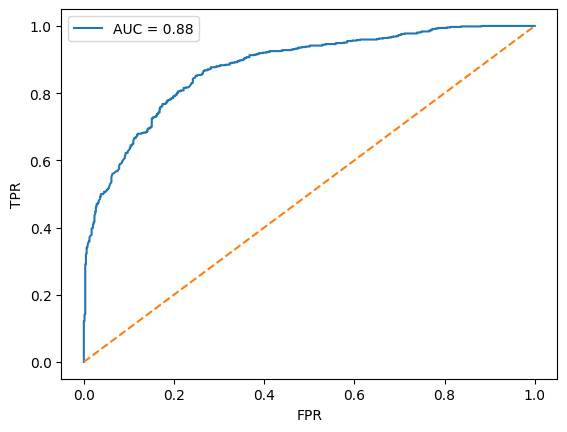

In [29]:
## ======== YOUR CODE HERE ======== ##

## Set appropriate X label, Y label and Title for the graph
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


## ================================ ##

#### Cross validation

In [42]:
## ======== YOUR CODE HERE ======== ##

## cv=5
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())



## ================================ ##

Cross Validation Scores: [0.78493387 0.78608396 0.78090857 0.783084   0.79401611]
Average Accuracy: 0.7858053019108768


## <b>SVM</b>
#### Use default parameters unless mentioned

In [32]:
## ======== YOUR CODE HERE ======== ##
from sklearn.svm import SVC

model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



## ================================ ##

#### Plot confusion matrix

In [33]:
## ======== YOUR CODE HERE ======== ##

## Use display labels as per your choice.
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))


## ================================ ##

[[522 115]
 [147 520]]


#### Print classification report

In [35]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


## ================================ ##

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       637
           1       0.82      0.78      0.80       667

    accuracy                           0.80      1304
   macro avg       0.80      0.80      0.80      1304
weighted avg       0.80      0.80      0.80      1304



#### Print accuracy score

In [36]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))


## ================================ ##

0.799079754601227


#### Print ROC-AUC score

In [38]:
## ======== YOUR CODE HERE ======== ##
from sklearn.svm import SVC

model = SVC(probability=True, random_state=42)
model.fit(X_train, y_train)

## Note: Use predict_proba!!! Read documentation/google it
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(auc)


## ================================ ##

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.8737464078008093


#### Plot ROC-AUC curve

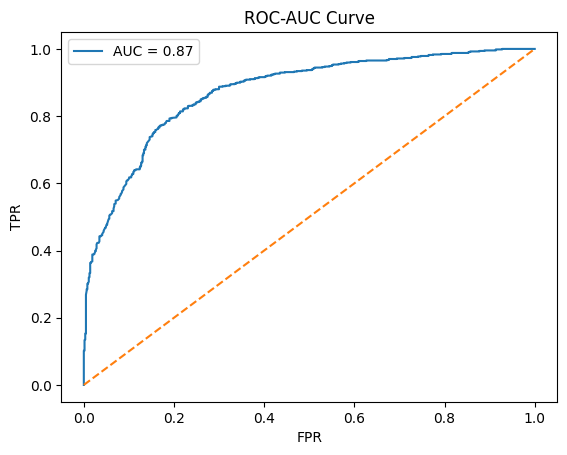

In [39]:
## ======== YOUR CODE HERE ======== ##

## Set appropriate X label, Y label and Title for the graph
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()


## ================================ ##

#### Cross validation

In [41]:
## ======== YOUR CODE HERE ======== ##

## cv=5
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

model = make_pipeline(
    StandardScaler(),
    SVC()
)

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())


## ================================ ##

Cross Validation Scores: [0.78205865 0.7786084  0.77285796 0.79113924 0.80207135]
Average Accuracy: 0.7853471202515103


# Congratulations! Assignment Completed!